In [3]:
import pickle
import pandas as pd
import shap
import matplotlib.pyplot as plt
from sklearn.metrics import classification_report, roc_auc_score


# import matplotlib
# print(matplotlib.__version__)
# print(matplotlib.pyplot)
# with open("xgb_model.pkl", "rb") as f:
#     model = pickle.load(f)

# test_df = pd.read_csv("test.csv")
# X_test  = test_df.drop(columns=["TenYearCHD", "stratify"])
# y_test  = test_df["TenYearCHD"]
# y_pred  = model.predict(X_test)

# # Split by sex (male=1, female=0)
# female_mask = test_df["male"] == 0
# male_mask   = test_df["male"] == 1

# for label, mask in [("Female", female_mask), ("Male", male_mask)]:
#     X = X_test[mask]
#     y_true = y_test[mask]
#     y_p    = model.predict(X)
#     y_prob = model.predict_proba(X)[:, 1]
#     print(f"\n── {label} ──────────────────────────────")
#     print(classification_report(y_true, y_p))
#     print(f"AUROC: {roc_auc_score(y_true, y_prob):.3f}")

with open("models/baseline_models/cardio_xgb_baseline_model.pkl", "rb") as f:
    model = pickle.load(f)

In [4]:
test_df = pd.read_csv("data/test_train_val_sets/cardio_baseline_test.csv")
X_test = test_df.drop(columns=["cardio", "stratify"])
y_test = test_df["cardio"]
y_pred = model.predict(X_test)
# print(X_test.columns.tolist())



Index(['gender', 'height', 'weight', 'ap_hi', 'ap_lo', 'cholesterol', 'gluc',
       'smoke', 'alco', 'active', 'age_years'],
      dtype='str')
Index(['gender', 'height', 'weight', 'ap_hi', 'ap_lo', 'cholesterol', 'gluc',
       'smoke', 'alco', 'active', 'cardio', 'age_years', 'stratify'],
      dtype='str')
False-negative women: 1348


c:\Users\kavis\OneDrive\Desktop\Study Resources\Year 3\Diss\Code\Dissertation_ExplainableAI\.venv\Lib\site-packages\sklearn\utils\validation.py:2691: UserWarning: X does not have valid feature names, but StandardScaler was fitted with feature names
  warnings.warn(



Feature comparison (woman vs matched male):
            FN Woman Matched Male
age_years         54           54
ap_hi            120          120
cholesterol        1            1
weight          69.0         69.0


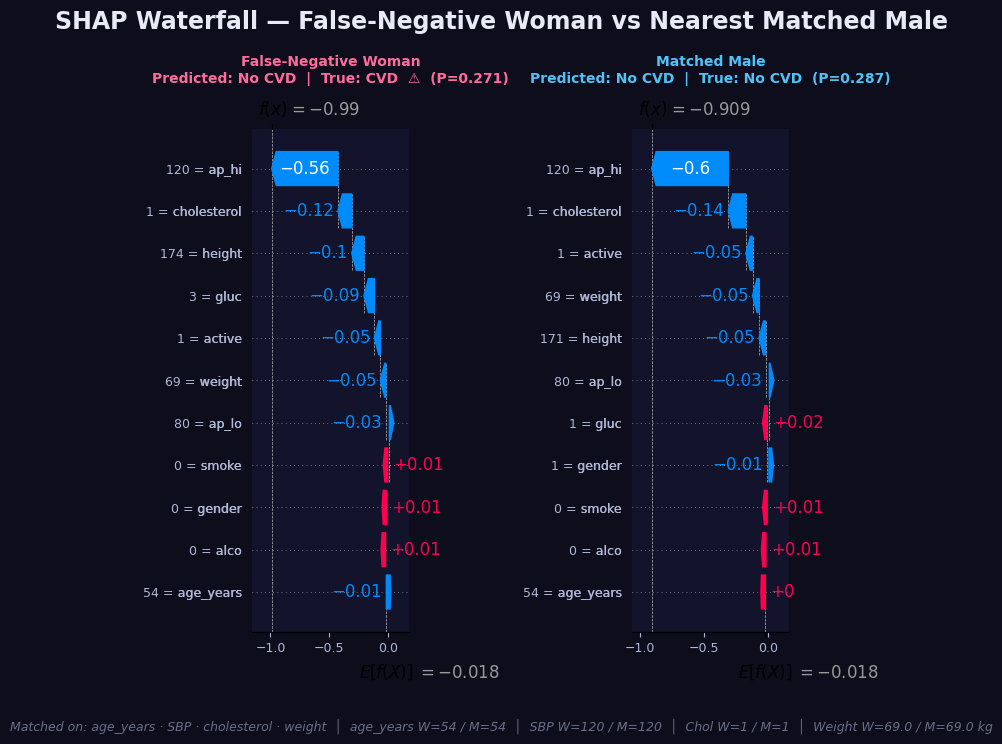


Top SHAP drivers (sorted by |woman SHAP|):
    feature  shap_woman  shap_male  diff (W-M)
      ap_hi     -0.5616    -0.6001     +0.0385
cholesterol     -0.1174    -0.1381     +0.0207
     height     -0.1033    -0.0507     -0.0526
       gluc     -0.0881    +0.0176     -0.1058
     active     -0.0503    -0.0523     +0.0020
     weight     -0.0470    -0.0513     +0.0043
      ap_lo     -0.0300    -0.0298     -0.0002
      smoke     +0.0141    +0.0139     +0.0002
     gender     +0.0093    -0.0145     +0.0238
       alco     +0.0093    +0.0100     -0.0007


In [5]:
# ── Additional code: SHAP False-Negative Analysis ────────────────────────────
# Paste this after your existing model evaluation code
# import shap

import numpy as np
from sklearn.preprocessing import StandardScaler

print(X_test.columns)
print(test_df.columns)
MATCHING_FEATURES = ["age_years", "ap_hi", "cholesterol", "weight"]

# 1. Identify false-negative women (true=1, predicted=0, gender=0)
fn_mask    = (y_test.values == 1) & (y_pred == 0) & (test_df["gender"].values == 0)
fn_women   = test_df[fn_mask].copy()
fn_women_X = X_test[fn_mask].copy()
print(f"False-negative women: {len(fn_women)}")

# 2. Pick most representative FN woman (closest to median profile)
fn_std     = fn_women[MATCHING_FEATURES].std().replace(0, 1)
fn_median  = fn_women[MATCHING_FEATURES].median()
distances  = fn_women[MATCHING_FEATURES].apply(
    lambda row: np.linalg.norm((row - fn_median) / fn_std), axis=1
)
rep_idx     = distances.idxmin()
rep_woman   = fn_women.loc[rep_idx]
rep_woman_X = X_test.loc[rep_idx]

# 3. Find nearest male in test set (z-score normalised L2 distance)
males   = test_df[test_df["gender"] == 1].copy()
males_X = X_test[test_df["gender"].values == 1].copy()

scaler = StandardScaler()
scaler.fit(pd.concat([fn_women[MATCHING_FEATURES], males[MATCHING_FEATURES]]))

woman_scaled = scaler.transform(rep_woman[MATCHING_FEATURES].values.reshape(1, -1))
males_scaled = scaler.transform(males[MATCHING_FEATURES])

best_pos   = np.argmin(np.linalg.norm(males_scaled - woman_scaled, axis=1))
rep_male   = males.iloc[best_pos]
rep_male_X = males_X.iloc[best_pos]

print("\nFeature comparison (woman vs matched male):")
print(pd.DataFrame({
    "FN Woman":     rep_woman[MATCHING_FEATURES].values,
    "Matched Male": rep_male[MATCHING_FEATURES].values,
}, index=MATCHING_FEATURES))

# 4. SHAP explanations
explainer = shap.TreeExplainer(model)
woman_df  = pd.DataFrame(rep_woman_X.values.reshape(1, -1), columns=X_test.columns)
male_df   = pd.DataFrame(rep_male_X.values.reshape(1, -1),  columns=X_test.columns)
sv_woman  = explainer(woman_df)
sv_male   = explainer(male_df)

prob_woman = model.predict_proba(woman_df.values)[0, 1]
prob_male  = model.predict_proba(male_df.values)[0, 1]

# 5. Side-by-side waterfall plots
fig, axes = plt.subplots(1, 2, figsize=(26, 10))
fig.patch.set_facecolor("#0d0d1b")

panels = [
    dict(sv=sv_woman, ax=axes[0], title="False-Negative Woman",
         subtitle=f"Predicted: No CVD  |  True: CVD  ⚠️  (P={prob_woman:.3f})",
         accent="#ff6b9d"),
    dict(sv=sv_male,  ax=axes[1], title="Matched Male",
         subtitle=f"Predicted: {'CVD' if model.predict(male_df.values)[0]==1 else 'No CVD'}  "
                  f"|  True: {'CVD' if rep_male['cardio']==1 else 'No CVD'}  (P={prob_male:.3f})",
         accent="#4fc3f7"),
]

for p in panels:
    plt.sca(p["ax"])
    shap.plots.waterfall(p["sv"][0], max_display=12, show=False)
    p["ax"].set_facecolor("#13132b")
    for spine in p["ax"].spines.values():
        spine.set_edgecolor("#252540")
    p["ax"].tick_params(colors="#b0b8d8", labelsize=9)
    p["ax"].xaxis.label.set_color("#b0b8d8")
    p["ax"].set_title(f"{p['title']}\n{p['subtitle']}", color=p["accent"], fontsize=10, fontweight="bold", pad=12)    
fig.suptitle("SHAP Waterfall — False-Negative Woman vs Nearest Matched Male",
             fontsize=17, fontweight="bold", color="#e8eaf6", y=1.02)
fig.text(0.5, -0.01,
         f"Matched on: age_years · SBP · cholesterol · weight  │  "
         f"age_years W={int(rep_woman['age_years'])} / M={int(rep_male['age_years'])}  │  "
         f"SBP W={int(rep_woman['ap_hi'])} / M={int(rep_male['ap_hi'])}  │  "
         f"Chol W={int(rep_woman['cholesterol'])} / M={int(rep_male['cholesterol'])}  │  "
         f"Weight W={rep_woman['weight']:.1f} / M={rep_male['weight']:.1f} kg",
         ha="center", fontsize=9, color="#6a6d88", style="italic")

plt.tight_layout(pad=3.0)
plt.subplots_adjust(top=0.85)
plt.savefig("shap_fn_woman_vs_matched_male.png", dpi=150,
            bbox_inches="tight", facecolor=fig.get_facecolor())
plt.show()

# 6. Console SHAP driver summary
print("\nTop SHAP drivers (sorted by |woman SHAP|):")
print(pd.DataFrame({
    "feature":    X_test.columns,
    "shap_woman": sv_woman[0].values,
    "shap_male":  sv_male[0].values,
    "diff (W-M)": sv_woman[0].values - sv_male[0].values,
}).sort_values("shap_woman", key=abs, ascending=False).head(10).to_string(
    index=False, float_format="{:+.4f}".format))



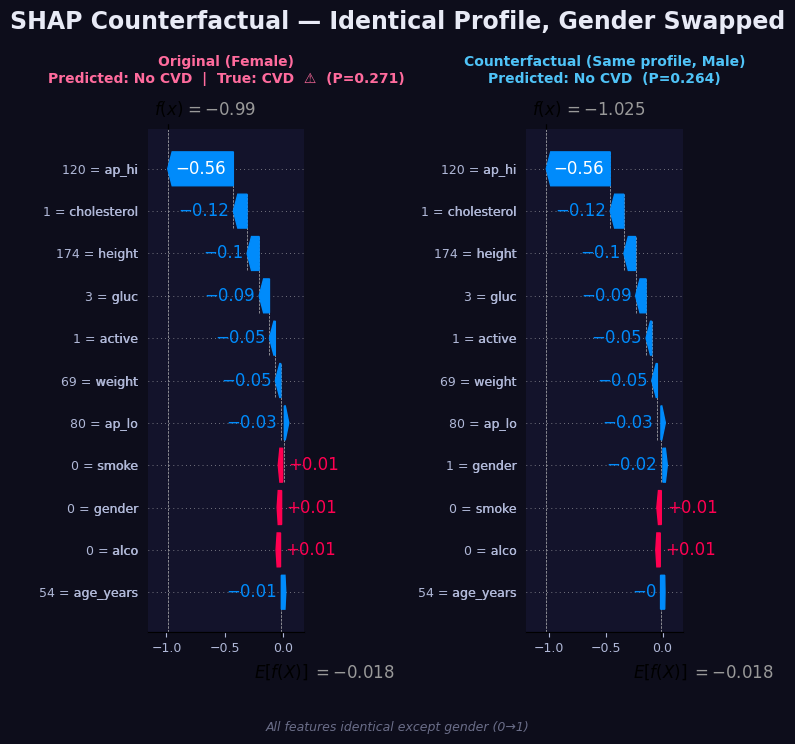


Original (Female) CVD probability:       0.271
Counterfactual (Male) CVD probability:   0.264
Probability difference (M-F):            -0.007


In [6]:
# 7. Counterfactual: swap gender for the FN woman
woman_counterfactual = woman_df.copy()
woman_counterfactual["gender"] = 1  # flip to male

sv_counterfactual = explainer(woman_counterfactual)
prob_counterfactual = model.predict_proba(woman_counterfactual.values)[0, 1]

# Plot original woman vs gender-swapped version
fig, axes = plt.subplots(1, 2, figsize=(26, 10))
fig.patch.set_facecolor("#0d0d1b")

panels = [
    dict(sv=sv_woman, ax=axes[0], title="Original (Female)",
         subtitle=f"Predicted: No CVD  |  True: CVD  ⚠️  (P={prob_woman:.3f})",
         accent="#ff6b9d"),
    dict(sv=sv_counterfactual, ax=axes[1], title="Counterfactual (Same profile, Male)",
         subtitle=f"Predicted: {'CVD' if model.predict(woman_counterfactual.values)[0]==1 else 'No CVD'}  (P={prob_counterfactual:.3f})",
         accent="#4fc3f7"),
]

for p in panels:
    plt.sca(p["ax"])
    shap.plots.waterfall(p["sv"][0], max_display=12, show=False)
    p["ax"].set_facecolor("#13132b")
    for spine in p["ax"].spines.values():
        spine.set_edgecolor("#252540")
    p["ax"].tick_params(colors="#b0b8d8", labelsize=9)
    p["ax"].xaxis.label.set_color("#b0b8d8")
    p["ax"].set_title(f"{p['title']}\n{p['subtitle']}", color=p["accent"], fontsize=10, fontweight="bold", pad=12)

fig.suptitle("SHAP Counterfactual — Identical Profile, Gender Swapped",
             fontsize=17, fontweight="bold", color="#e8eaf6", y=1.02)
fig.text(0.5, -0.01, "All features identical except gender (0→1)",
         ha="center", fontsize=9, color="#6a6d88", style="italic")

plt.tight_layout(pad=3.0)
plt.subplots_adjust(top=0.85)
plt.savefig("shap_counterfactual_gender.png", dpi=150,
            bbox_inches="tight", facecolor=fig.get_facecolor())
plt.show()

print(f"\nOriginal (Female) CVD probability:       {prob_woman:.3f}")
print(f"Counterfactual (Male) CVD probability:   {prob_counterfactual:.3f}")
print(f"Probability difference (M-F):            {prob_counterfactual - prob_woman:+.3f}")


False-negative women vs true-positive women:
             FN_mean  TP_mean  FN_median  TP_median  Difference_FN_minus_TP
age_years     52.784   55.948       54.0       57.0                  -3.164
ap_hi        117.662  140.865      120.0      140.0                 -23.203
ap_lo         77.269   87.284       80.0       90.0                 -10.015
cholesterol    1.186    1.702        1.0        1.0                  -0.515
gluc           1.161    1.359        1.0        1.0                  -0.198
weight        70.260   77.407       69.0       75.0                  -7.147
height       162.558  160.822      163.0      160.0                   1.736
smoke          0.013    0.018        0.0        0.0                  -0.006
alco           0.022    0.027        0.0        0.0                  -0.005
active         0.817    0.782        1.0        1.0                   0.035

Mean SHAP comparison: FN women vs TP women
             FN_mean_SHAP  TP_mean_SHAP  Difference_FN_minus_TP  FN_mean_a

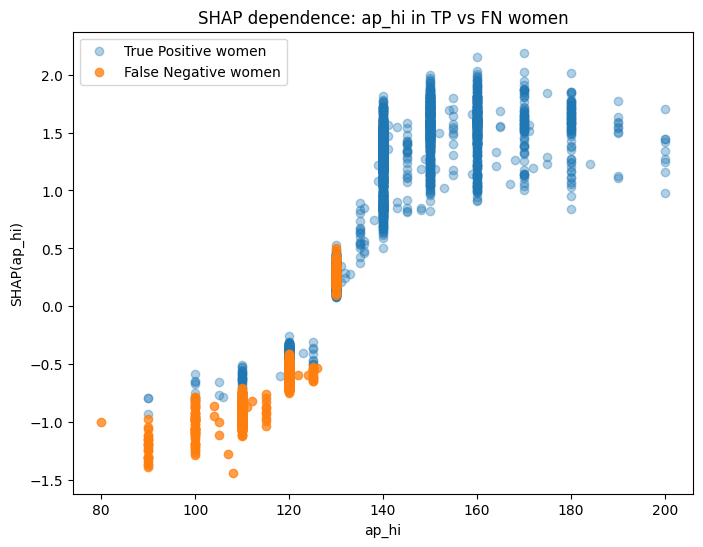


Predicted probability summary:
FN women:
count    1348.0000
mean        0.3309
std         0.1057
min         0.0367
25%         0.2542
50%         0.3480
75%         0.4124
max         0.5000

TP women:
count    3026.0000
mean        0.7732
std         0.1120
min         0.5000
25%         0.7137
50%         0.8209
75%         0.8538
max         0.9132

False-negative phenotype summary:
dominant_negative_feature
ap_hi          89.2%
age_years       4.9%
cholesterol     4.4%
weight          1.0%
smoke           0.2%
alco            0.1%
height          0.1%
ap_lo           0.1%
Name: proportion, dtype: str


In [7]:
# 1. Compare false-negative women vs true-positive women
tp_mask  = (y_test.values == 1) & (y_pred == 1) & (test_df["gender"].values == 0)
tp_women = test_df[tp_mask].copy()

compare_features = ["age_years", "ap_hi", "ap_lo", "cholesterol", "gluc", "weight", "height", "smoke", "alco", "active"]

summary_compare = pd.DataFrame({
    "FN_mean": fn_women[compare_features].mean(),
    "TP_mean": tp_women[compare_features].mean(),
    "FN_median": fn_women[compare_features].median(),
    "TP_median": tp_women[compare_features].median(),
    "Difference_FN_minus_TP": fn_women[compare_features].mean() - tp_women[compare_features].mean()
}).round(3)

print("\nFalse-negative women vs true-positive women:")
print(summary_compare.to_string())
# 2. Build SHAP tables for all female test cases
female_mask = (test_df["gender"].values == 0)
male_mask = (test_df["gender"].values == 1)


X_test_female = X_test[female_mask].copy()
test_female   = test_df[female_mask].copy()
y_test_female = y_test.values[female_mask]
y_pred_female = y_pred[female_mask]

sv_female = explainer(X_test_female)
shap_female_df = pd.DataFrame(sv_female.values, columns=X_test.columns, index=X_test_female.index)

shap_female_df["y_true"] = y_test_female
shap_female_df["y_pred"] = y_pred_female
shap_female_df["false_negative"] = ((shap_female_df["y_true"] == 1) & (shap_female_df["y_pred"] == 0)).astype(int)
shap_female_df["true_positive"]  = ((shap_female_df["y_true"] == 1) & (shap_female_df["y_pred"] == 1)).astype(int)
# 3. Which features most strongly push down FN predictions?
# 9. Mean SHAP in FN vs TP women
fn_shap = shap_female_df[shap_female_df["false_negative"] == 1][X_test.columns]
tp_shap = shap_female_df[shap_female_df["true_positive"] == 1][X_test.columns]

shap_compare = pd.DataFrame({
    "FN_mean_SHAP": fn_shap.mean(),
    "TP_mean_SHAP": tp_shap.mean(),
    "Difference_FN_minus_TP": fn_shap.mean() - tp_shap.mean(),
    "FN_mean_abs_SHAP": fn_shap.abs().mean(),
    "TP_mean_abs_SHAP": tp_shap.abs().mean()
}).sort_values("Difference_FN_minus_TP")

print("\nMean SHAP comparison: FN women vs TP women")
print(shap_compare.round(4).to_string())

# Interpretation:

# very negative FN_mean_SHAP = feature pushes missed women toward “No CVD”

# FN_mean_SHAP much lower than TP_mean_SHAP = possible under-response or over-reassurance

# 4. Most common top negative feature in FN women
# 10. Most common dominant negative contributor in FN women
top_negative_feature_fn = fn_shap.idxmin(axis=1)
top_negative_counts = top_negative_feature_fn.value_counts()

print("\nMost common top negative SHAP feature in false-negative women:")
print(top_negative_counts.to_string())

# This is great for phrases like:

# “The most common dominant downward contributor in false-negative women was systolic blood pressure.”

# 5. Top 2 negative contributors per FN case
# 11. Top 2 negative contributors per FN case
def top_n_negative_features(row, n=2):
    return row.sort_values().head(n).index.tolist()

top2_neg_fn = fn_shap.apply(top_n_negative_features, axis=1)

top2_df = pd.DataFrame(top2_neg_fn.tolist(), index=fn_shap.index, columns=["neg_1", "neg_2"])

print("\nTop 2 negative contributors in first 10 FN women:")
print(top2_df.head(10).to_string())
# 6. Plot SHAP dependence for FN vs TP women for one feature
# 12. FN vs TP dependence scatter for one feature
import matplotlib.pyplot as plt

feature = "ap_hi"
idx = X_test.columns.get_loc(feature)

fn_mask_female = shap_female_df["false_negative"] == 1
tp_mask_female = shap_female_df["true_positive"] == 1

plt.figure(figsize=(8, 6))
plt.scatter(
    X_test_female.loc[tp_mask_female, feature],
    sv_female.values[tp_mask_female, idx],
    alpha=0.35,
    label="True Positive women"
)
plt.scatter(
    X_test_female.loc[fn_mask_female, feature],
    sv_female.values[fn_mask_female, idx],
    alpha=0.75,
    label="False Negative women"
)
plt.xlabel(feature)
plt.ylabel(f"SHAP({feature})")
plt.title(f"SHAP dependence: {feature} in TP vs FN women")
plt.legend()
plt.show()

# Repeat this for:

# "age_years"

# "ap_hi"

# "cholesterol"

# "gluc"

# 7. Predicted probability distribution for FN women
# 13. Are false negatives near-misses or hard misses?
y_pred_proba = model.predict_proba(X_test)[:, 1]
test_df["pred_proba"] = y_pred_proba

fn_women_probs = test_df.loc[fn_mask, "pred_proba"]
tp_women_probs = test_df.loc[tp_mask, "pred_proba"]

print("\nPredicted probability summary:")
print("FN women:")
print(fn_women_probs.describe().round(4).to_string())

print("\nTP women:")
print(tp_women_probs.describe().round(4).to_string())

# This tells you whether FN women were:

# just below threshold

# or strongly misclassified as low risk

# 8. Simple error phenotype table
# 14. Simple FN phenotype summary using dominant negative feature
fn_pattern_table = pd.DataFrame({
    "dominant_negative_feature": top_negative_feature_fn
})

print("\nFalse-negative phenotype summary:")
print(fn_pattern_table["dominant_negative_feature"].value_counts(normalize=True).mul(100).round(1).astype(str) + "%")

In [8]:
from sklearn.metrics import recall_score

female_recall = recall_score(y_test[female_mask], y_pred[female_mask])
male_recall = recall_score(y_test[male_mask], y_pred[male_mask])

print(f"Female Recall (Sensitivity): {female_recall:.3f}")
print(f"Male Recall (Sensitivity): {male_recall:.3f}")

Female Recall (Sensitivity): 0.692
Male Recall (Sensitivity): 0.668


             FN_mean_SHAP  TP_mean_SHAP  Difference_FN_minus_TP  FN_abs_SHAP  TP_abs_SHAP
ap_hi             -0.5953        0.8972                 -1.4925       0.6415       1.0328
cholesterol       -0.0777        0.1536                 -0.2313       0.1777       0.2798
age_years         -0.0228        0.1384                 -0.1612       0.2763       0.2244
ap_lo             -0.0491        0.0709                 -0.1200       0.0615       0.0997
weight            -0.0317        0.0337                 -0.0653       0.1196       0.0990
active            -0.0054        0.0049                 -0.0102       0.0710       0.0520
height             0.0089        0.0144                 -0.0055       0.0257       0.0286
gender             0.0055        0.0079                 -0.0024       0.0067       0.0094
alco               0.0068        0.0037                  0.0031       0.0166       0.0112
gluc               0.0082        0.0046                  0.0036       0.0230       0.0613
smoke     

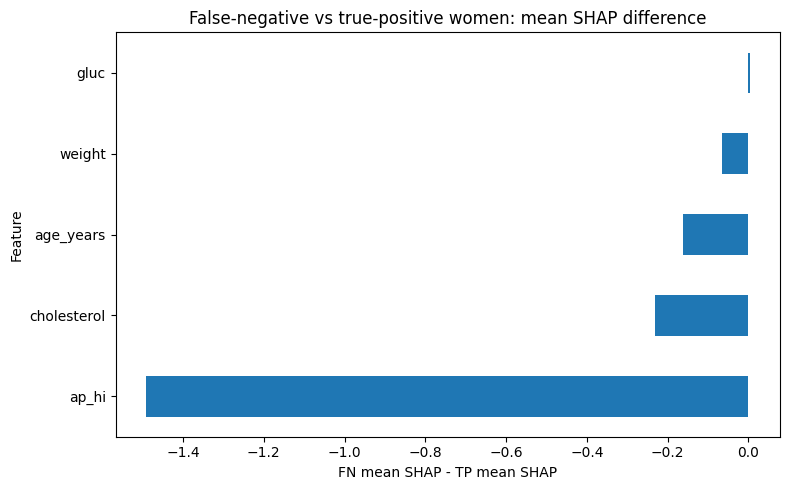

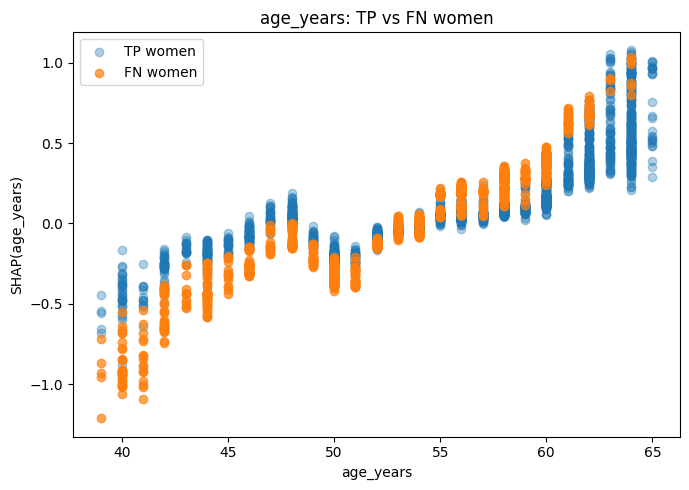

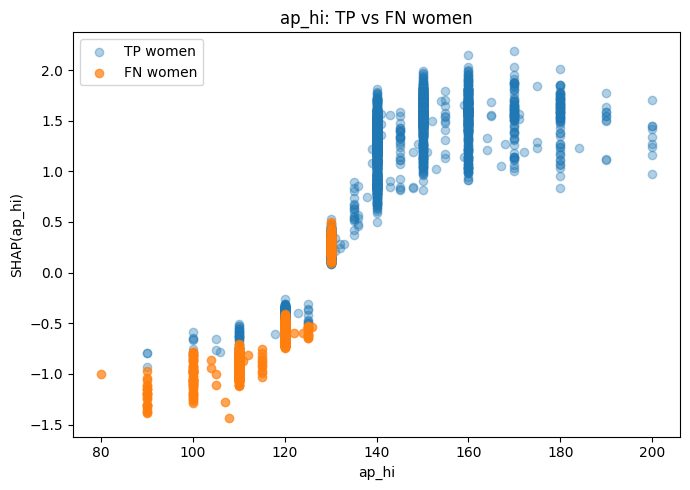

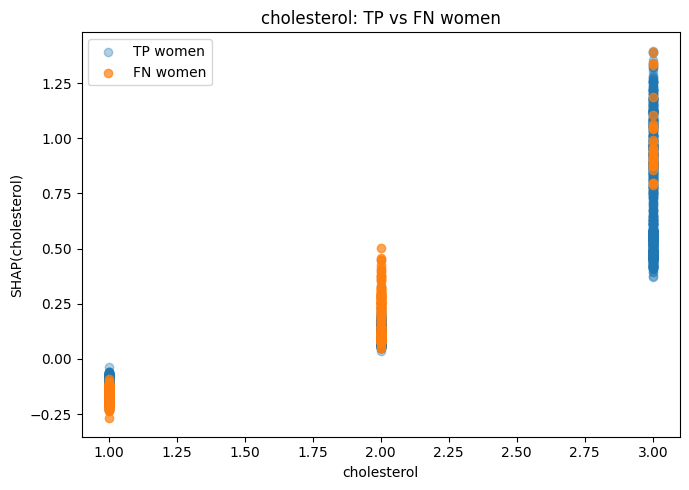

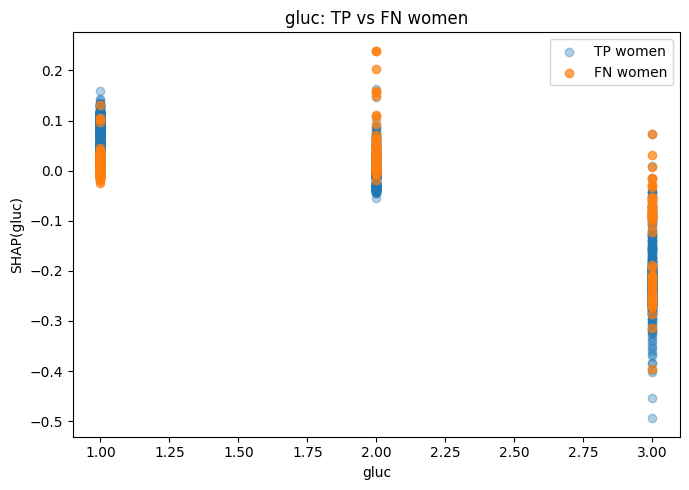

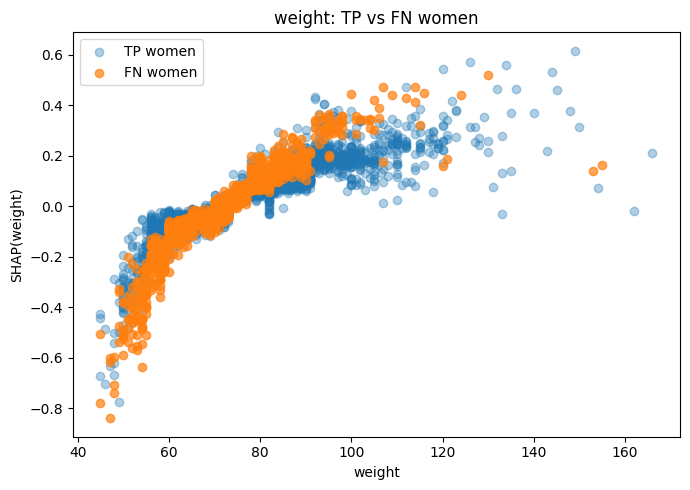

In [9]:
# Compare FN vs TP women for mean SHAP by feature
import pandas as pd
import matplotlib.pyplot as plt

# masks
female_mask = (X_test["gender"].values == 0)
fn_mask = female_mask & (y_test.values == 1) & (y_pred == 0)
tp_mask = female_mask & (y_test.values == 1) & (y_pred == 1)

# SHAP values for all test women
explainer = shap.TreeExplainer(model)
sv_all = explainer(X_test).values
shap_df = pd.DataFrame(sv_all, columns=X_test.columns, index=X_test.index)

# mean SHAP comparison
fn_mean_shap = shap_df.loc[fn_mask].mean()
tp_mean_shap = shap_df.loc[tp_mask].mean()

compare = pd.DataFrame({
    "FN_mean_SHAP": fn_mean_shap,
    "TP_mean_SHAP": tp_mean_shap,
    "Difference_FN_minus_TP": fn_mean_shap - tp_mean_shap,
    "FN_abs_SHAP": shap_df.loc[fn_mask].abs().mean(),
    "TP_abs_SHAP": shap_df.loc[tp_mask].abs().mean()
}).sort_values("Difference_FN_minus_TP")

print(compare.round(4).to_string())

# features you care about most
features_to_plot = ["age_years", "ap_hi", "cholesterol", "gluc", "weight"]

# bar plot of mean SHAP difference
plt.figure(figsize=(8, 5))
compare.loc[features_to_plot, "Difference_FN_minus_TP"].sort_values().plot(kind="barh")
plt.xlabel("FN mean SHAP - TP mean SHAP")
plt.ylabel("Feature")
plt.title("False-negative vs true-positive women: mean SHAP difference")
plt.tight_layout()
plt.show()

# FN vs TP dependence scatter for selected features
for feature in features_to_plot:
    idx = X_test.columns.get_loc(feature)

    plt.figure(figsize=(7, 5))
    plt.scatter(
        X_test.loc[tp_mask, feature],
        sv_all[tp_mask, idx],
        alpha=0.35,
        label="TP women"
    )
    plt.scatter(
        X_test.loc[fn_mask, feature],
        sv_all[fn_mask, idx],
        alpha=0.7,
        label="FN women"
    )
    plt.xlabel(feature)
    plt.ylabel(f"SHAP({feature})")
    plt.title(f"{feature}: TP vs FN women")
    plt.legend()
    plt.tight_layout()
    plt.show()